## 1. Problem Statement and Basic Metrics Analysis

### Import required Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Loading the data

In [ ]:
df_netflix = pd.read_csv('netflix.csv')

### Basic Data Analysis

In [ ]:
# shape of the data (rows, columns)
print("Shape of the dataset (rows, columns):", df_netflix.shape)

# value counts for content type
print("\nValue counts for 'type':")
print(df_netflix['type'].value_counts())

Shape of the dataset (rows, columns): (8807, 12)

Value counts for 'type':
type
Movie      6131
TV Show    2676
Name: count, dtype: int64


Problem Statement:

The business objective is to analyze Netflix's content data to provide insights that will inform decisions on what types of shows and movies to produce and how to expand the business in different countries.

Basic Metrics:

The dataset consists of 8,807 rows and 12 columns. The primary content types are Movies and TV Shows.

## 2. Data Observations

In [ ]:
# Data types and non-null values
print("Data types and non-null values:")
print(df_netflix.info())

# Convert 'date_added' to datetime for time-based analysis
df_netflix['date_added'] = pd.to_datetime(df_netflix['date_added'], errors='coerce')

# Missing values for all columns
print("\nMissing values in each column:")
print(df_netflix.isnull().sum())

Data types and non-null values:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None

Missing values in each column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        98
release_year       0
rating         

**Insights**:

The dataset has 8,807 rows and 12 columns. The release_year is an int64, and most other columns are object type.

Missing values were identified in several columns, notably
director, cast, and country

#3. Non-Graphical Analysis

In [ ]:
# Top 10 content-producing countries
print("Top 10 countries for content production:")
print(df_netflix['country'].value_counts().head(10))

# Pre-processing: Unnest the 'listed_in' column to count genres
df_listed_in = df_netflix.assign(listed_in=df_netflix['listed_in'].str.split(', ')).explode('listed_in')

# Top 10 most common genres
print("\nTop 10 Genres:")
print(df_listed_in['listed_in'].value_counts().head(10))

Top 10 countries for content production:
country
United States     2818
India              972
United Kingdom     419
Japan              245
South Korea        199
Canada             181
Spain              145
France             124
Mexico             110
Egypt              106
Name: count, dtype: int64

Top 10 Genres:
listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: count, dtype: int64


**Insights**:

Content Type: 6,131 Movies and 2,676 TV Shows.

Top Countries: The United States leads with 2,818 titles, followed by India (972), the United Kingdom (419), Japan (245), and South Korea (199).

Top Genres: The most common genres are International Movies, Dramas, and Comedies.

## 4. Visual Analysis

/tmp/ipython-input-3968926318.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='type', data=df_netflix, palette='viridis', ax=axes[0, 0])
/tmp/ipython-input-3968926318.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_countries.values, y=top_countries.index, palette='magma', ax=axes[0, 1])
/tmp/ipython-input-3968926318.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_genres.values, y=top_genres.index, palette='plasma', ax=axes[1, 1])


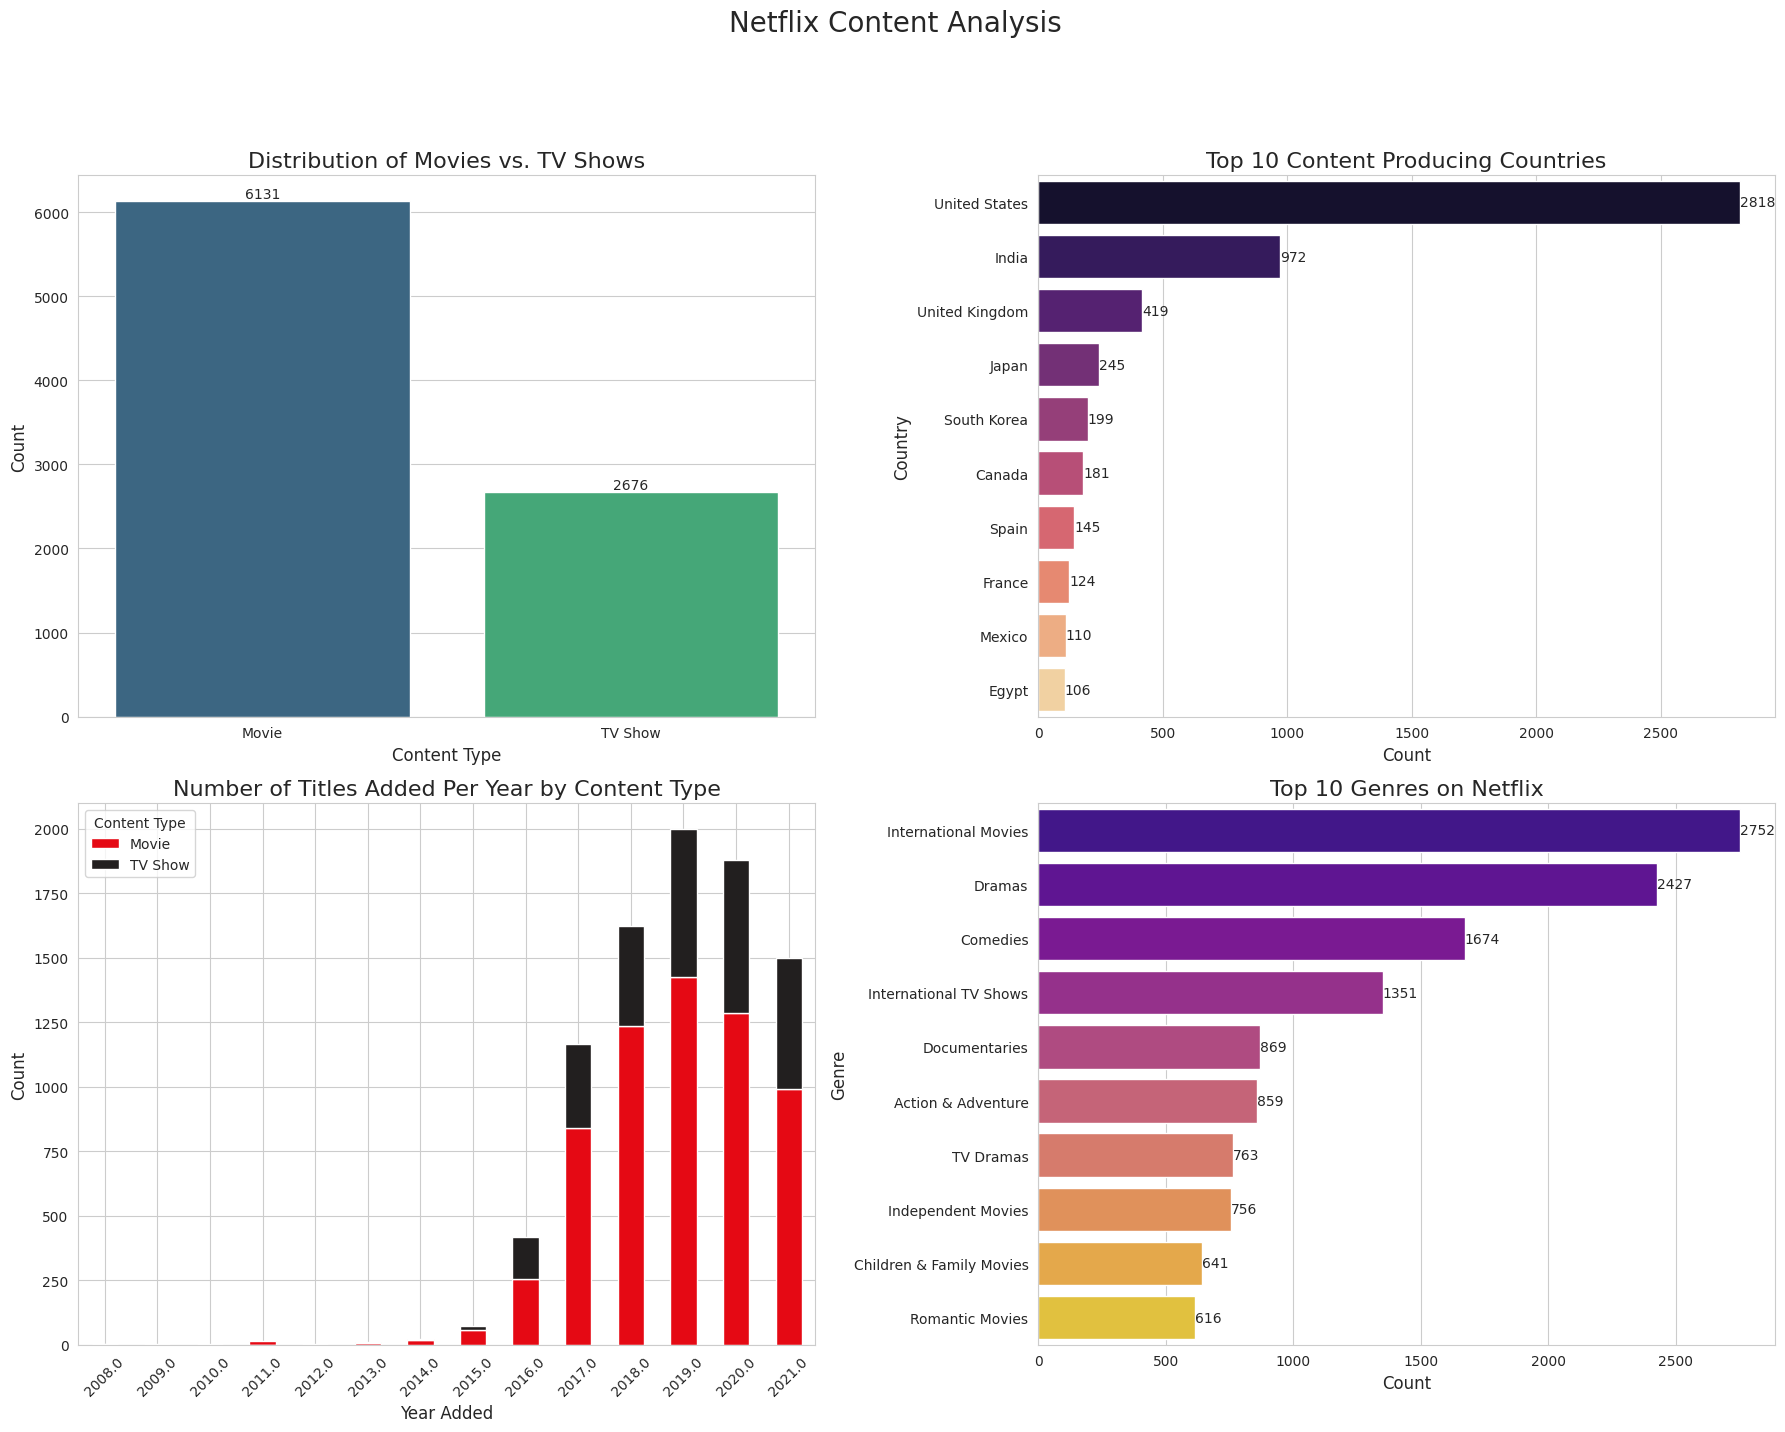

/tmp/ipython-input-3968926318.py:51: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df_netflix['release_year'], bins=30, kde=True, color='#e50914')


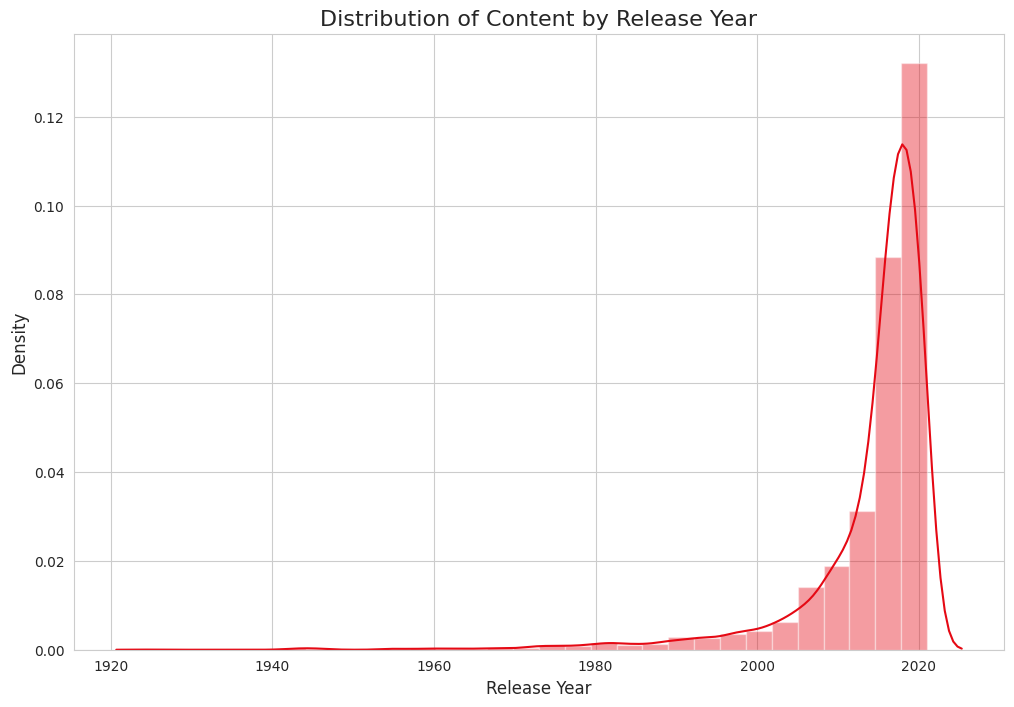

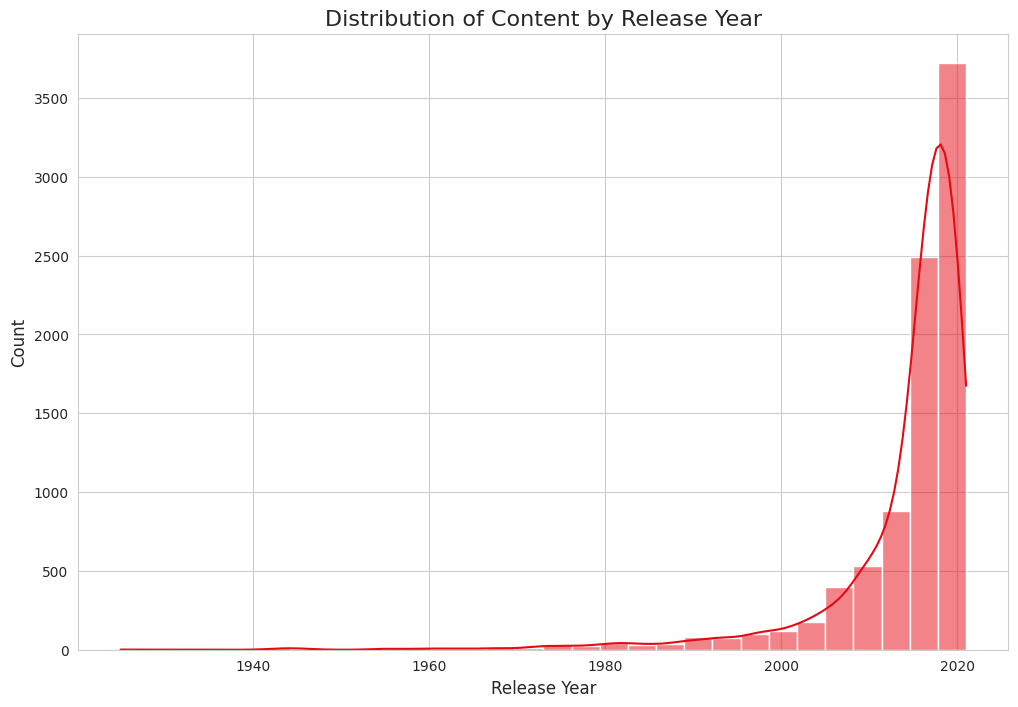

In [ ]:
# Set style for plots
sns.set_style("whitegrid")

# Creating a figure and subplots for multiple charts
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Netflix Content Analysis', fontsize=20, y=1.02)

# Plot 1: Distribution of Content Type (Movies vs TV Shows)
sns.countplot(x='type', data=df_netflix, palette='viridis', ax=axes[0, 0])
axes[0, 0].set_title('Distribution of Movies vs. TV Shows', fontsize=16)
axes[0, 0].set_xlabel('Content Type', fontsize=12)
axes[0, 0].set_ylabel('Count', fontsize=12)
for container in axes[0, 0].containers:
    axes[0, 0].bar_label(container)

# Plot 2: Top 10 Content Producing Countries
top_countries = df_netflix['country'].value_counts().head(10)
sns.barplot(x=top_countries.values, y=top_countries.index, palette='magma', ax=axes[0, 1])
axes[0, 1].set_title('Top 10 Content Producing Countries', fontsize=16)
axes[0, 1].set_xlabel('Count', fontsize=12)
axes[0, 1].set_ylabel('Country', fontsize=12)
for container in axes[0, 1].containers:
    axes[0, 1].bar_label(container)

# Plot 3: Number of Titles Added Per Year by Type
# Creating 'year_added' column
df_netflix['year_added'] = df_netflix['date_added'].dt.year
yearly_content_counts = df_netflix.groupby(['year_added', 'type']).size().unstack(fill_value=0)
yearly_content_counts.plot(kind='bar', stacked=True, color=['#e50914', '#221f1f'], ax=axes[1, 0])
axes[1, 0].set_title('Number of Titles Added Per Year by Content Type', fontsize=16)
axes[1, 0].set_xlabel('Year Added', fontsize=12)
axes[1, 0].set_ylabel('Count', fontsize=12)
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].legend(title='Content Type')

# Plot 4: Top 10 Genres
df_listed_in_unnested = df_netflix.assign(listed_in=df_netflix['listed_in'].str.split(', ')).explode('listed_in')
top_genres = df_listed_in_unnested['listed_in'].value_counts().head(10)
sns.barplot(x=top_genres.values, y=top_genres.index, palette='plasma', ax=axes[1, 1])
axes[1, 1].set_title('Top 10 Genres on Netflix', fontsize=16)
axes[1, 1].set_xlabel('Count', fontsize=12)
axes[1, 1].set_ylabel('Genre', fontsize=12)
for container in axes[1, 1].containers:
    axes[1, 1].bar_label(container)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Creating the distplot for 'release_year'
plt.figure(figsize=(12, 8))
sns.distplot(df_netflix['release_year'], bins=30, kde=True, color='#e50914')

# Add titles and labels
plt.title('Distribution of Content by Release Year', fontsize=16)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Density', fontsize=12)

# Display the plot
plt.show()

# Creating a figure and axes
plt.figure(figsize=(12, 8))

# Generate the histogram
sns.histplot(df_netflix['release_year'], bins=30, kde=True, color='#e50914')

# Add titles and labels
plt.title('Distribution of Content by Release Year', fontsize=16)
plt.xlabel('Release Year', fontsize=12)
plt.ylabel('Count', fontsize=12)

# Display the plot
plt.show()


##For continuous variable(s)
**Visualizations Insights**:    

 Univariate Analysis: The countplot (Distribution of Movies vs Tv Shows) shows a clear dominance of movies.

 The barplot (Top 10 Content Producing Countries) for countries shows the United States leading by a large margin.

 The barplot (Top 10 genres on Netflix) reveals a strong focus on a few key categories, with International Movies and Dramas being the most prevalent

 The displot visually confirms that Netflix's content library is overwhelmingly dominated by movies. The bar for movies is significantly taller than the bar for TV shows, showing their numerical dominance

 The histogram shows that the majority of content in Netflix's catalog was released in recent years, particularly from around 2010 to 2020. The distribution is heavily skewed to the right, with very few titles from earlier decades

 Bivariate Analysis: The stacked bar chart (Number of Titles added per year by Content Type) shows that Netflix's content acquisition peaked in 2019, with a steady increase in TV show additions over recent years.

/tmp/ipython-input-2830026915.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='duration', data=df_movies, palette='viridis')


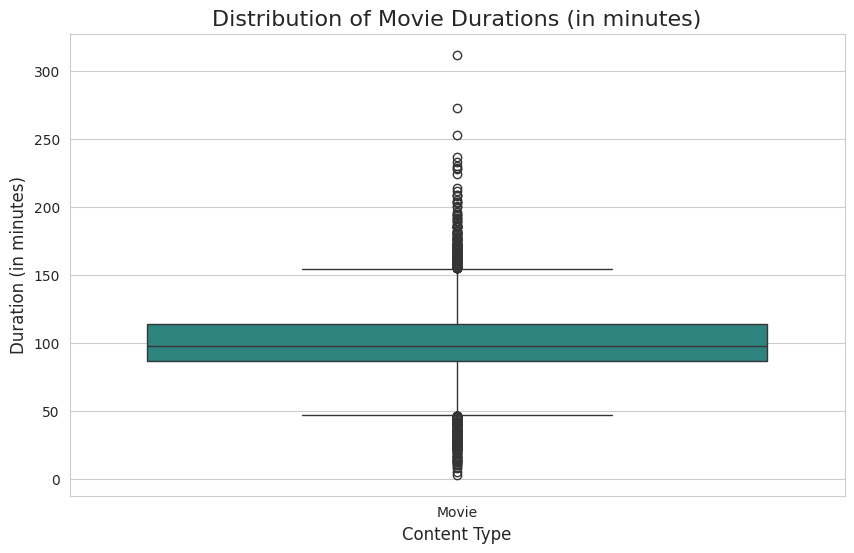

/tmp/ipython-input-2830026915.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='type', y='duration', data=df_tv_shows, palette='plasma')


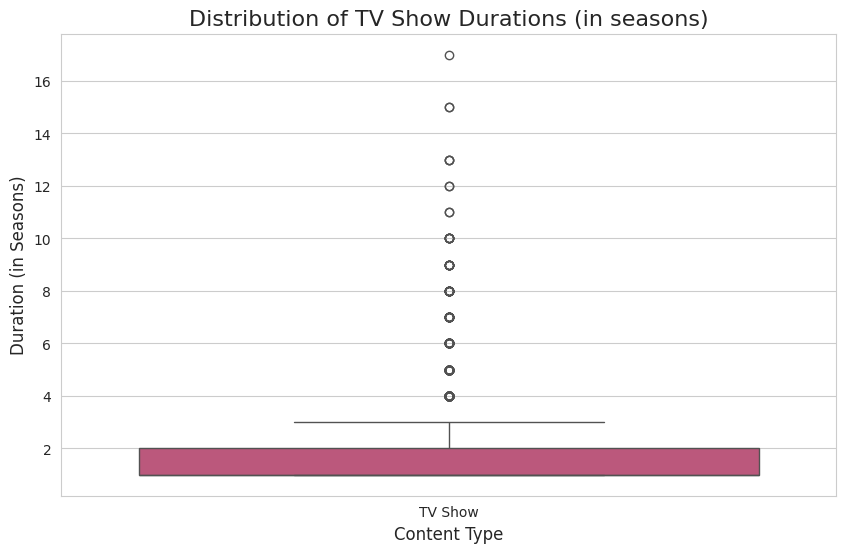


Statistical summary for movie durations:
count    6128.000000
mean       99.577187
std        28.290593
min         3.000000
25%        87.000000
50%        98.000000
75%       114.000000
max       312.000000
Name: duration, dtype: float64

Statistical summary for TV show durations:
count    2676.000000
mean        1.764948
std         1.582752
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        17.000000
Name: duration, dtype: float64


In [ ]:
# Drop rows with missing values in the 'duration' column to avoid the ValueError
df_netflix.dropna(subset=['duration'], inplace=True)

# Separate the dataset into movies and TV shows
df_movies = df_netflix[df_netflix['type'] == 'Movie'].copy()
df_tv_shows = df_netflix[df_netflix['type'] == 'TV Show'].copy()

# Pre-processing for movies: convert duration to integer
df_movies['duration'] = df_movies['duration'].str.replace(' min', '').astype(int)

# Pre-processing for TV shows: convert duration to integer
df_tv_shows['duration'] = df_tv_shows['duration'].str.replace(' Seasons', '').str.replace(' Season', '').astype(int)

# Create a boxplot for movie durations
plt.figure(figsize=(10, 6))
sns.boxplot(x='type', y='duration', data=df_movies, palette='viridis')
plt.title('Distribution of Movie Durations (in minutes)', fontsize=16)
plt.ylabel('Duration (in minutes)', fontsize=12)
plt.xlabel('Content Type', fontsize=12)
plt.savefig('movie_duration_boxplot.png')
plt.show()

# Create a boxplot for TV show seasons
plt.figure(figsize=(10, 6))
sns.boxplot(x='type', y='duration', data=df_tv_shows, palette='plasma')
plt.title('Distribution of TV Show Durations (in seasons)', fontsize=16)
plt.ylabel('Duration (in Seasons)', fontsize=12)
plt.xlabel('Content Type', fontsize=12)
plt.savefig('tv_show_duration_boxplot.png')
plt.show()

# Print statistical summary for both dataframes to provide additional context
print("\nStatistical summary for movie durations:")
print(df_movies['duration'].describe())

print("\nStatistical summary for TV show durations:")
print(df_tv_shows['duration'].describe())

##For categorical variable(s)
##1. Distribution of Movie Durations

 The boxplot for movies shows the distribution of runtimes in minutes.

 **Insights**:

 The median movie duration is approximately 98 minutes, meaning half of the movies are shorter than this, and half are longer.

 The majority of movies fall within a tight range, with the middle 50% (the interquartile range) lasting between 87 and 114 minutes.

 There is a large number of outliers (represented by the dots), which are movies significantly longer than the typical runtime, with some stretching up to 312 minutes.

##2. Distribution of TV Show Seasons

 The boxplot for TV shows visualizes the distribution of the number of seasons.

 **Insights**:

 The median number of seasons is 1, indicating that over half of the TV shows on Netflix are single-season series.

 The interquartile range is also very small, with the middle 50% of shows having between 1 and 2 seasons.

 The plot shows a significant number of outliers, with some shows having up to 17 seasons, but these are extremely rare.

## 5. Missing Value & Outlier Check

In [ ]:
# Count missing values for all columns
print("Missing values in each column:")
print(df_netflix.isnull().sum())

Missing values in each column:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        98
release_year       0
rating             4
duration           3
listed_in          0
description        0
year_added        98
dtype: int64


**Insights**: As shown in the code output, several columns have missing values.

director has 2,634 missing values, cast has 825, and country has 831 have the highest number of missing values.

The problem statement did not require treatment of these values, so they were noted for consideration in further analysis.

## 6. Insights from Non-Graphical and Visual Analysis


**6.1 Comments on the Range of Attributes**

The dataset's attributes reveal a broad scope of content and a significant period of company growth.

release_year: The range of release years, from 1942 to 2021, shows that Netflix has a diverse back catalog of older films and is actively acquiring new, contemporary titles.

date_added: The data shows a massive acceleration in content acquisition, particularly from 2016 to 2021. This period marks a pivotal phase of rapid expansion for the platform.

duration: The range of content duration is highly varied. For movies, it spans from very short films (3 minutes) to very long ones (312 minutes), while for TV shows, the number of seasons ranges from 1 to 17.

**6.2 Comments on the Distribution of Variables and Their Relationship**

The analysis of variable distributions and relationships provides key insights into Netflix’s strategic priorities.

The content library's distribution is heavily skewed toward movies, which outnumber TV shows by more than a 2-to-1 ratio. However, a crucial relationship exists between content type and the year it was added: the proportion of TV shows has been steadily increasing since 2016, indicating a strategic shift.

The content production is highly centralized, with the United States being the dominant country, but the strong presence of content from India and other non-U.S. nations highlights a commitment to a global content strategy.

The most prevalent genres, International Movies and Dramas, have a long-tailed distribution, confirming that Netflix focuses on broad, mass-appeal content.

**6.3 Comments for Each Univariate and Bivariate Plot**

Univariate Plots:

Content Type (countplot): This plot clearly shows the disproportionate number of movies versus TV shows, with movies making up about 69.6% of the catalog.

Release Year (histogram/distplot): The histogram reveals that a significant majority of the content was released in the last decade, with a peak around 2018-2021. This shows that Netflix’s library is primarily composed of new or relatively recent titles.

Bivariate Plot:

Titles Added Per Year by Type (stacked bar chart): This plot is the most revealing. It shows a massive surge in content additions peaking in 2019, followed by a slight decline. More importantly, it highlights a strategic pivot: while movie additions stabilized or slightly decreased after 2019, TV show additions continued to grow, suggesting a deliberate effort to build the TV show library for improved subscriber engagement.




##7. Business Insights

1. **The Great Pivot: From Quantity to Loyalty**

 Our analysis shows that while movies still form the backbone of Netflix's content library, the company is undergoing a strategic pivot toward TV shows. The data reveals a steady, aggressive increase in TV show acquisitions since 2016. This isn't a random shift; it's a deliberate move to foster subscriber loyalty. TV shows, with their episodic nature, are designed to keep viewers engaged and coming back for more, which is crucial for reducing churn and ensuring long-term subscription revenue.

2. **The World is Our Stage: Global First**

 The data on content-producing countries is a powerful testament to Netflix’s global vision. While the United States remains the primary content source, the rapid growth of titles from countries like India and South Korea is a clear indicator of a "global-first" strategy. Netflix isn't just catering to a Western audience; it is actively investing in localized content to capture new markets and create a truly diverse and globally resonant content library. This approach allows them to connect with subscribers on a more personal, cultural level, making the service more indispensable in non-US territories.


3. **The Art of Mass Appeal: Serving the Core Audience**

 The content library is heavily populated with dramas and comedies, highlighting a strategy built on mass appeal. By prioritizing these universally popular genres, Netflix ensures a broad and accessible entry point for new subscribers. This focus on mainstream content allows the company to cast a wide net, attracting a diverse audience and maximizing its subscriber base. The success of this strategy is evident in the platform’s continued growth and market dominance.

# 8. Recommendations

1. **Focus on TV Shows for Long-Term Engagement**

 While Netflix's library is currently dominated by movies, the data reveals a clear shift toward TV shows. This isn't just a trend; it's a strategic move to secure long-term subscriber loyalty. Unlike movies, which offer a one-time viewing experience, TV shows with multiple seasons are designed to keep viewers engaged for months or even years. To capitalize on this, Netflix should:
 Prioritize funding and production for multi-season TV shows, especially those that can build strong fan communities.
 Strategically release episodes (e.g., in batches or weekly) to extend viewer engagement and generate sustained social media buzz.

2. **Leverage the Global Content Engine**

 The data shows that content from countries like India, the UK, and South Korea is a key part of Netflix’s growth. This suggests that the platform’s future lies in its ability to be a global-first content hub, not just an American streaming service. To strengthen this position, Netflix should:
 Expand its investment in original content from diverse, high-growth markets. This not only attracts new subscribers in those regions but also offers unique, compelling content to a global audience.
 Identify and partner with local production companies and talent in emerging markets to create authentic stories that resonate with regional audiences.

3. **Double Down on High-Demand Genres**

 The analysis confirms that Dramas and Comedies are the most popular and widely consumed genres on the platform. This provides a clear, low-risk path for content production. To maximize its return on investment, Netflix should:
 Continue to produce a consistent pipeline of high-quality dramas and comedies, both as original series and acquired films, to satisfy the majority of its user base.
 Use data to identify sub-genres within dramas and comedies (e.g., rom-coms, crime dramas) that are particularly popular in specific regions, and then produce content to meet that localized demand.